In [1]:
import pandas as pd

df = pd.read_csv('../data/cleaned_master.csv', parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date'])

print(df.shape)
print(df.head(3))

(115030, 31)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10-10 21:25:13   
2          2017-10-04 19:55:00           2017-10-10 21:25:13   

  order_estimated_delivery_date                customer_unique_id  \
0                    2017-10-18  7c396fd4830fd04220f754e42b4e5bff   
1                    2017-10-18  7c396fd48

In [2]:
# reference date = day after last order in dataset
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("reference date:", reference_date)

reference date: 2018-08-30 15:00:37


In [3]:
# calculate RFM metrics per customer
rfm = df.groupby('customer_unique_id').agg(
    recency = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary = ('payment_value', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head())

(93350, 4)
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89


In [4]:
# score each metric 1-5 using quantiles
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5])

print(rfm.head())

                 customer_unique_id  recency  frequency  monetary r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19       4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22       1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62       2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89       2   

  f_score m_score  
0       1       4  
1       1       1  
2       1       2  
3       1       1  
4       1       4  


In [5]:
# combine scores into single RFM score
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# label segments based on r_score and f_score
def label_segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(label_segment, axis=1)
print(rfm['segment'].value_counts())

segment
Lost             22360
At Risk          22228
Loyal            18823
New Customers    14980
Champions        14959
Name: count, dtype: int64


In [6]:
rfm.to_csv('../data/rfm_scores.csv', index=False)
print("saved. shape:", rfm.shape)

saved. shape: (93350, 9)


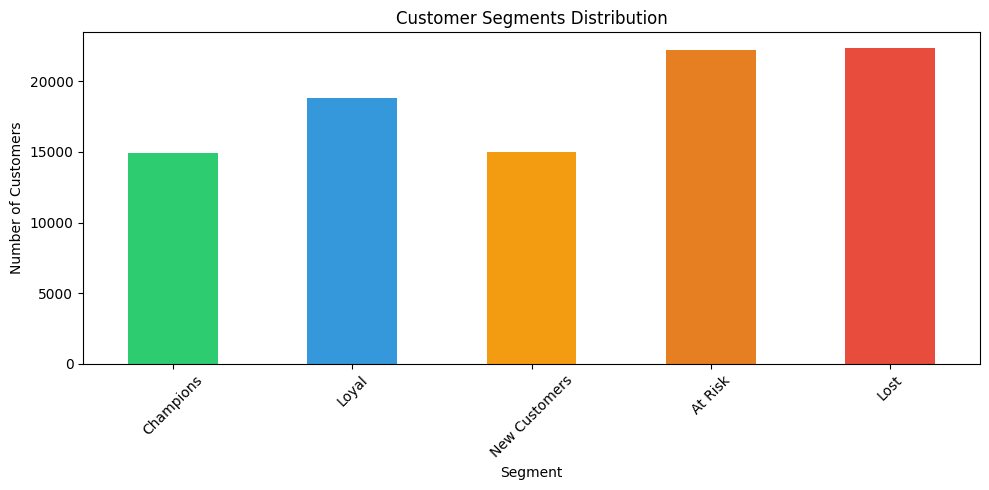

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# segment distribution bar chart
plt.figure(figsize=(10, 5))
order = ['Champions', 'Loyal', 'New Customers', 'At Risk', 'Lost']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
rfm['segment'].value_counts().reindex(order).plot(kind='bar', color=colors)
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/segment_distribution.png')
plt.show()